# Comparaison des horloges épigénétiques avec pyaging

**Objectif** : Appliquer les principales horloges de méthylation ADN (Horvath, Hannum, GrimAge2, etc.) sur notre dataset EPICv2 (400 sujets, ~894k CpG) et comparer leurs performances avec notre modèle custom.

**Package** : [pyaging](https://github.com/rsinghlab/pyaging) — bibliothèque Python regroupant 150+ horloges épigénétiques

**Optimisation mémoire** : On ne charge que les ~40k CpG nécessaires aux horloges (au lieu de 894k), réduisant la mémoire de 1.4 GB à ~64 MB.

## Sections
1. Installation et imports
2. Identification des CpG nécessaires
3. Chargement sélectif des données
4. Prédiction avec les horloges épigénétiques
5. Évaluation des performances (brutes)
6. Calibration des horloges (CV 5-fold) + Ensemble
7. Comparaison avec notre modèle custom
8. Visualisations

## 1. Installation et imports

In [118]:
# Installation de pyaging (si pas déjà installé)
import subprocess, sys
try:
    import pyaging
    print(f'pyaging déjà installé (version {pyaging.__version__})')
except ImportError:
    print('Installation de pyaging...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'pyaging', '-q'])
    import pyaging
    print(f'pyaging installé (version {pyaging.__version__})')

pyaging déjà installé (version 0.1.30)


In [119]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path
import time
import os
import torch
import urllib.request

import pyaging as pya

from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from scipy import stats

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')

# Configuration
DATA_DIR = Path('Data')
DATA_PATH = DATA_DIR / 'c_sample.csv'
PYAGING_DIR = 'pyaging_data'
os.makedirs(PYAGING_DIR, exist_ok=True)

print('Imports OK')

Imports OK


## 2. Identification des CpG nécessaires aux horloges

Au lieu de charger les 894k CpG (1.4 GB en RAM), on identifie d'abord les CpG utilisés par chaque horloge et on ne charge que ceux-là.

**Horloges sélectionnées** :
- **Horvath2013** (353 CpG) — 1ère génération, pan-tissu, référence historique
- **Hannum** (71 CpG) — 1ère génération, sang
- **GrimAge2** (1032 CpG) — 2ème génération, risque de mortalité
- **DunedinPACE** (20000 CpG) — 3ème génération, rythme de vieillissement
- **AltumAge** (20318 CpG) — Deep learning, réseau de neurones

> **Note** : PhenoAge est exclu car il utilise des données de biochimie sanguine (albumine, créatinine, etc.), pas des CpG.

In [120]:
# Horloges à tester (celles qui utilisent des CpG)
CLOCKS = ['Horvath2013', 'Hannum', 'GrimAge2', 'DunedinPACE', 'AltumAge']

# Télécharger les modèles et extraire les listes de CpG
print('Téléchargement des modèles et extraction des CpG nécessaires...\n')

clock_features = {}
all_needed_cpgs = set()

for clock in CLOCKS:
    clock_lower = clock.lower()
    pt_path = os.path.join(PYAGING_DIR, f'{clock_lower}.pt')
    
    # Télécharger si nécessaire
    if not os.path.exists(pt_path):
        url = f'https://pyaging.s3.amazonaws.com/clocks/weights0.1.0/{clock_lower}.pt'
        print(f'  Téléchargement de {clock}...')
        urllib.request.urlretrieve(url, pt_path)
    
    # Charger le modèle et extraire les features
    model = torch.load(pt_path, map_location='cpu', weights_only=False)
    features = model.features if hasattr(model, 'features') else []
    
    # Compter les CpG (commencent par 'cg')
    cpg_features = [f for f in features if f.startswith('cg')]
    clock_features[clock] = features
    all_needed_cpgs.update(cpg_features)
    
    print(f'  {clock:15s} : {len(features):6d} features ({len(cpg_features)} CpG)')

print(f'\nTotal CpG uniques nécessaires : {len(all_needed_cpgs):,}')
print(f'Réduction : {len(all_needed_cpgs):,} / 894,006 = {len(all_needed_cpgs)/894006*100:.1f}%')

Téléchargement des modèles et extraction des CpG nécessaires...

  Horvath2013     :    353 features (353 CpG)
  Hannum          :     71 features (69 CpG)
  GrimAge2        :   1032 features (1030 CpG)
  DunedinPACE     :  20000 features (20000 CpG)
  AltumAge        :  20318 features (20318 CpG)

Total CpG uniques nécessaires : 40,410
Réduction : 40,410 / 894,006 = 4.5%


## 3. Chargement sélectif des données

On ne charge que les ~40k lignes CpG nécessaires du CSV de 6 GB.

In [121]:
# Chargement des annotations
annot = pd.read_csv(DATA_DIR / 'annot_projet.csv')
annot = annot.dropna(subset=['age', 'Sample_description']).copy()
annot['Sample_description'] = annot['Sample_description'].astype(str)
annot = annot.set_index('Sample_description')

print(f'Annotations : {len(annot)} échantillons')
print(f'Âge : {annot["age"].min():.1f} - {annot["age"].max():.1f} ans')
print(f'Sexe : {annot["female"].value_counts().to_dict()}')

Annotations : 400 échantillons
Âge : 18.1 - 90.0 ans
Sexe : {True: 214, False: 186}


In [122]:
# Charger les noms de CpG et trouver les indices des CpG nécessaires
cpg_names = pd.read_csv(DATA_DIR / 'cpg_names_projet.csv', usecols=['cpg_names'])
cpg_names = cpg_names['cpg_names'].astype(str).tolist()

# Construire un mapping nom -> index pour recherche rapide
cpg_to_idx = {name: idx for idx, name in enumerate(cpg_names)}

# Trouver les indices des CpG nécessaires
needed_indices = sorted([
    cpg_to_idx[cpg] for cpg in all_needed_cpgs if cpg in cpg_to_idx
])
needed_names = [cpg_names[i] for i in needed_indices]

found = len(needed_indices)
total = len(all_needed_cpgs)
print(f'CpG trouvés dans notre dataset : {found:,} / {total:,} ({found/total*100:.1f}%)')
print(f'CpG manquants : {total - found:,}')

CpG trouvés dans notre dataset : 36,823 / 40,410 (91.1%)
CpG manquants : 3,587


In [123]:
# Chargement sélectif : ne lire que les lignes nécessaires du CSV
# On lit par chunks et extrait les lignes qui correspondent aux indices nécessaires

print(f'Chargement sélectif de {len(needed_indices):,} CpG (sur 894k)...')
t0 = time.time()

CHUNK_SIZE = 10000
needed_set = set(needed_indices)
needed_arr = np.array(needed_indices)

rows = []
row_names = []
global_row = 0

for chunk in pd.read_csv(DATA_PATH, chunksize=CHUNK_SIZE):
    chunk_end = global_row + len(chunk)
    
    # Trouver les indices nécessaires dans ce chunk
    pos_start = np.searchsorted(needed_arr, global_row)
    pos_end = np.searchsorted(needed_arr, chunk_end)
    
    local_indices = needed_arr[pos_start:pos_end] - global_row
    
    if len(local_indices) > 0:
        selected = chunk.iloc[local_indices]
        rows.append(selected)
        for idx in needed_arr[pos_start:pos_end]:
            row_names.append(cpg_names[idx])
    
    global_row = chunk_end
    
    if global_row % 200000 == 0:
        print(f'  {global_row:,} / 894,006 lignes scannées, {len(row_names):,} CpG extraits...')

# Assembler la matrice (CpG x samples)
beta_selected = pd.concat(rows, axis=0)
beta_selected.index = row_names

# Transposer : (CpG, samples) -> (samples, CpG)
beta_df = beta_selected.T.astype(np.float32)
del beta_selected, rows  # libérer mémoire

t1 = time.time()
mem_mb = beta_df.memory_usage(deep=True).sum() / 1e6
n_nan = beta_df.isna().sum().sum()
pct_nan = beta_df.isna().mean().mean() * 100
print(f'\nChargement terminé en {t1-t0:.1f}s')
print(f'Shape : {beta_df.shape} (samples x CpG)')
print(f'Mémoire : {mem_mb:.0f} MB (au lieu de ~1400 MB pour 894k CpG)')
print(f'NaN avant imputation : {n_nan:,} ({pct_nan:.2f}%)')

# --- Imputation par la moyenne (par CpG) ---
# Chaque CpG manquant est remplacé par la moyenne de ce CpG sur les 400 samples
col_means = beta_df.mean()
beta_df = beta_df.fillna(col_means)

# Colonnes entièrement NaN -> remplir par 0.5 (valeur neutre pour beta-values)
still_nan = beta_df.isna().sum().sum()
if still_nan > 0:
    beta_df = beta_df.fillna(0.5)

print(f'NaN après imputation moyenne : {beta_df.isna().sum().sum()}')

Chargement sélectif de 36,823 CpG (sur 894k)...
  200,000 / 894,006 lignes scannées, 8,260 CpG extraits...
  400,000 / 894,006 lignes scannées, 16,392 CpG extraits...
  600,000 / 894,006 lignes scannées, 24,226 CpG extraits...
  800,000 / 894,006 lignes scannées, 32,768 CpG extraits...

Chargement terminé en 28.8s
Shape : (400, 36823) (samples x CpG)
Mémoire : 59 MB (au lieu de ~1400 MB pour 894k CpG)
NaN avant imputation : 149,016 (1.01%)
NaN après imputation moyenne : 0


In [124]:
# Vérifier la couverture des CpG pour chaque horloge
print('Couverture des CpG par horloge :\n')
available_cpgs = set(beta_df.columns)

for clock in CLOCKS:
    features = clock_features[clock]
    cpg_feats = [f for f in features if f.startswith('cg')]
    found = sum(1 for f in cpg_feats if f in available_cpgs)
    pct = found / len(cpg_feats) * 100 if cpg_feats else 0
    print(f'  {clock:15s} : {found:5d} / {len(cpg_feats):5d} CpG disponibles ({pct:.1f}%)')

Couverture des CpG par horloge :

  Horvath2013     :   340 /   353 CpG disponibles (96.3%)
  Hannum          :    62 /    69 CpG disponibles (89.9%)
  GrimAge2        :   845 /  1030 CpG disponibles (82.0%)
  DunedinPACE     : 17356 / 20000 CpG disponibles (86.8%)
  AltumAge        : 19527 / 20318 CpG disponibles (96.1%)


In [125]:
# Préparer le DataFrame pour pyaging
# Aligner avec les annotations
common_ids = [s for s in beta_df.index if s in annot.index]
print(f'Échantillons en commun : {len(common_ids)}')

beta_df = beta_df.loc[common_ids].copy()
annot_aligned = annot.loc[common_ids]

# Ajouter les métadonnées (pyaging attend 'female' en 0/1)
beta_df['age'] = annot_aligned['age'].values
beta_df['female'] = annot_aligned['female'].map(
    {True: 1, False: 0, 'TRUE': 1, 'FALSE': 0}
).values.astype(float)
beta_df['ethnicity'] = annot_aligned['ethnicity'].values

print(f'DataFrame : {beta_df.shape} ({beta_df.shape[1] - 3} CpG + 3 metadata)')

Échantillons en commun : 400
DataFrame : (400, 36826) (36823 CpG + 3 metadata)


In [126]:
# Conversion en AnnData
# Les données sont déjà imputées (moyenne par CpG) dans la cellule précédente
print('Conversion en AnnData...')
t0 = time.time()

adata = pya.pp.df_to_adata(
    beta_df,
    metadata_cols=['age', 'female', 'ethnicity'],
    imputer_strategy='mean'  # backup seulement, données déjà imputées
)

t1 = time.time()
print(f'\nConversion terminée en {t1-t0:.1f}s')
print(f'AnnData : {adata.shape[0]} samples x {adata.shape[1]} CpG')

Conversion en AnnData...
|-----> 🏗️ Starting df_to_adata function
|-----> ⚙️ Create anndata object started
|-----> ✅ Create anndata object finished [0.0203s]
|-----> ⚙️ Add metadata to anndata started
|-----------> Adding provided metadata to adata.obs
|-----> ✅ Add metadata to anndata finished [0.0007s]
|-----> ⚙️ Log data statistics started
|-----------> There are 400 observations
|-----------> There are 36823 features
|-----------> Total missing values: 0
|-----------> Percentage of missing values: 0.00%
|-----> ✅ Log data statistics finished [0.0076s]
|-----> ⚙️ Impute missing values started
|-----------> No missing values found. No imputation necessary
|-----> ✅ Impute missing values finished [0.0082s]
|-----> 🎉 Done! [0.0548s]

Conversion terminée en 0.1s
AnnData : 400 samples x 36823 CpG


## 4. Prédiction avec les horloges épigénétiques

In [127]:
# Prédiction avec toutes les horloges
print(f'Prédiction avec {len(CLOCKS)} horloges...\n')

t0 = time.time()
pya.pred.predict_age(adata, CLOCKS, dir=PYAGING_DIR, verbose=True)
t1 = time.time()

print(f'\nPrédictions terminées en {t1-t0:.1f}s')

Prédiction avec 5 horloges...

|-----> 🏗️ Starting predict_age function
|-----> ⚙️ Set PyTorch device started
|-----------> Using device: cpu
|-----> ✅ Set PyTorch device finished [0.0013s]
|-----> 🕒 Processing clock: horvath2013
|-----------> ⚙️ Load clock started
|-----------------> Data found in pyaging_data/horvath2013.pt
|-----------> ✅ Load clock finished [0.0015s]
|-----------> ⚙️ Check features in adata started
|-----------------? 13 out of 353 features (3.68%) are missing: ['cg01873645', 'cg07595943', 'cg11932564'], etc.
|-----------------> Using reference feature values for horvath2013
|-----------> ⚠️ Check features in adata finished [0.0142s]
|-----------> ⚙️ Predict ages with model started
|-----------------> There is no preprocessing necessary
|-----------------> The postprocessing method is anti_log_linear
|-----------------> in progress: 100.0000%
|-----------> ✅ Predict ages with model finished [0.0015s]
|-----------> ⚙️ Add predicted ages and clock metadata to adata s

In [128]:
# Aperçu des prédictions
pred_cols = [c for c in adata.obs.columns if c not in ['age', 'female', 'ethnicity']]
print(f'Colonnes de prédiction : {pred_cols}\n')

display_cols = ['age'] + pred_cols
print(adata.obs[display_cols].describe().to_string(float_format='%.2f'))

Colonnes de prédiction : ['horvath2013', 'hannum', 'grimage2', 'dunedinpace', 'altumage']

         age  horvath2013  hannum  grimage2  dunedinpace  altumage
count 400.00       400.00  400.00    400.00       400.00    400.00
mean   52.95        58.23   23.96     65.53         1.07     56.00
std    21.24        20.49   18.07      7.39         0.14     14.97
min    18.09        16.01  -11.90     52.33         0.36     22.59
25%    34.00        42.17    8.91     60.59         0.96     44.74
50%    53.55        59.33   24.47     64.74         1.06     55.15
75%    72.17        74.16   37.43     69.07         1.15     67.72
max    90.00       134.10   71.50    126.10         1.60     96.58


## 5. Évaluation des performances

Métriques :
- **MAE** : erreur absolue moyenne (années)
- **MedAE** : erreur absolue médiane
- **R²** : coefficient de détermination
- **Pearson r** : corrélation linéaire
- **Biais** : tendance à sur/sous-estimer

In [129]:
y_true = adata.obs['age'].values.astype(float)

results = []
pred_cols = [c for c in adata.obs.columns if c not in ['age', 'female', 'ethnicity']]

for clock_col in pred_cols:
    y_pred = adata.obs[clock_col].values.astype(float)
    
    valid = ~(np.isnan(y_pred) | np.isnan(y_true))
    if valid.sum() < 10:
        print(f'{clock_col}: trop peu de prédictions valides ({valid.sum()}), ignoré')
        continue
    
    yt, yp = y_true[valid], y_pred[valid]
    
    results.append({
        'horloge': clock_col,
        'n_valid': int(valid.sum()),
        'MAE': mean_absolute_error(yt, yp),
        'MedAE': np.median(np.abs(yt - yp)),
        'RMSE': np.sqrt(mean_squared_error(yt, yp)),
        'R²': r2_score(yt, yp),
        'Pearson r': stats.pearsonr(yt, yp)[0],
        'Biais moyen': np.mean(yp - yt),
    })

results_df = pd.DataFrame(results).sort_values('MAE')
results_df.index = range(1, len(results_df) + 1)
results_df.index.name = 'Rang'

print('=== Performances des horloges épigénétiques ===')
print(results_df.to_string(float_format='%.3f'))

=== Performances des horloges épigénétiques ===
          horloge  n_valid    MAE  MedAE   RMSE     R²  Pearson r  Biais moyen
Rang                                                                          
1     horvath2013      400  6.651  5.969  8.733  0.830      0.945        5.278
2        altumage      400  7.134  6.372  8.837  0.826      0.953        3.053
3        grimage2      400 18.745 16.411 22.723 -0.148      0.467       12.579
4          hannum      400 29.181 28.371 29.880 -0.984      0.945      -28.988
5     dunedinpace      400 51.887 52.356 56.035 -5.979      0.369      -51.887


In [130]:
# MAE par tranche d'âge
age_groups = {'<40': (0, 40), '40-65': (40, 65), '>65': (65, 120)}

# Horloges qui prédisent un âge chronologique (pas DunedinPACE = rythme de vieillissement)
age_clocks = [r['horloge'] for r in results if r['horloge'] != 'dunedinpace']

print('=== MAE par tranche d\'âge (prédictions brutes) ===')
print(f'{"Horloge":20s}', end='')
for group in age_groups:
    print(f'{group:>10s}', end='')
print(f'{"Global":>10s}')
print('-' * 60)

for clock_col in age_clocks:
    y_pred = adata.obs[clock_col].values.astype(float)
    valid = ~(np.isnan(y_pred) | np.isnan(y_true))
    
    print(f'{clock_col:20s}', end='')
    for group_name, (low, high) in age_groups.items():
        mask = valid & (y_true >= low) & (y_true < high)
        if mask.sum() > 0:
            mae_g = mean_absolute_error(y_true[mask], y_pred[mask])
            print(f'{mae_g:10.2f}', end='')
        else:
            print(f'{"N/A":>10s}', end='')
    
    mae_all = mean_absolute_error(y_true[valid], y_pred[valid])
    print(f'{mae_all:10.2f}')

print(f'\nNote : DunedinPACE mesure le rythme de vieillissement (valeurs ~1.0),')
print(f'pas l\'âge chronologique. Il est exclu de cette comparaison.')

=== MAE par tranche d'âge (prédictions brutes) ===
Horloge                    <40     40-65       >65    Global
------------------------------------------------------------
horvath2013               7.49      6.49      6.04      6.65
hannum                   24.73     28.30     34.10     29.18
grimage2                 33.93     13.70      9.74     18.75
altumage                 11.67      4.05      5.96      7.13

Note : DunedinPACE mesure le rythme de vieillissement (valeurs ~1.0),
pas l'âge chronologique. Il est exclu de cette comparaison.


## 6. Calibration des horloges

Les horloges pré-entraînées présentent un **biais systématique** sur nos données (décalage constant). C'est normal : elles ont été entraînées sur d'autres cohortes/plateformes.

**Calibration linéaire** : on ajuste une régression linéaire `âge_réel = a × âge_prédit + b` pour corriger le biais.

Pour éviter le data leakage, on utilise une **validation croisée 5-fold** : la calibration est entraînée sur 4/5 des données et appliquée sur le 1/5 restant.

In [131]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression

# Calibration par validation croisée 5-fold
print('=== Calibration linéaire (5-fold CV) ===\n')

kf = KFold(n_splits=5, shuffle=True, random_state=42)
calibrated_preds = {}

for clock_col in age_clocks:
    y_pred_raw = adata.obs[clock_col].values.astype(float)
    calibrated = np.zeros_like(y_pred_raw)
    
    for train_idx, test_idx in kf.split(y_true):
        # Entraîner la calibration sur le fold train
        lr = LinearRegression()
        lr.fit(y_pred_raw[train_idx].reshape(-1, 1), y_true[train_idx])
        # Appliquer sur le fold test
        calibrated[test_idx] = lr.predict(y_pred_raw[test_idx].reshape(-1, 1))
    
    calibrated_preds[clock_col] = calibrated
    
    # Stocker dans adata
    adata.obs[f'{clock_col}_cal'] = calibrated
    
    mae_raw = mean_absolute_error(y_true, y_pred_raw)
    mae_cal = mean_absolute_error(y_true, calibrated)
    bias_raw = np.mean(y_pred_raw - y_true)
    bias_cal = np.mean(calibrated - y_true)
    
    print(f'{clock_col:15s} : MAE {mae_raw:.2f} → {mae_cal:.2f}  '
          f'(biais {bias_raw:+.1f} → {bias_cal:+.1f})')

=== Calibration linéaire (5-fold CV) ===

horvath2013     : MAE 6.65 → 4.80  (biais +5.3 → +0.0)
hannum          : MAE 29.18 → 4.49  (biais -29.0 → -0.0)
grimage2        : MAE 18.75 → 15.85  (biais +12.6 → +0.1)
altumage        : MAE 7.13 → 4.63  (biais +3.1 → -0.0)


In [132]:
# Ensemble des horloges calibrées (moyenne pondérée par 1/MAE)
print('=== Ensemble des horloges calibrées ===\n')

# Calcul des poids (inverse du MAE calibré)
mae_per_clock = {}
for clock_col in age_clocks:
    mae_per_clock[clock_col] = mean_absolute_error(y_true, calibrated_preds[clock_col])

# Ensemble 1 : Moyenne simple de toutes les horloges calibrées
ensemble_simple = np.mean([calibrated_preds[c] for c in age_clocks], axis=0)
mae_ens_simple = mean_absolute_error(y_true, ensemble_simple)

# Ensemble 2 : Moyenne pondérée (1/MAE) de toutes les horloges calibrées
weights = {c: 1.0 / mae for c, mae in mae_per_clock.items()}
total_w = sum(weights.values())
weights = {c: w / total_w for c, w in weights.items()}
ensemble_weighted = np.sum([weights[c] * calibrated_preds[c] for c in age_clocks], axis=0)
mae_ens_weighted = mean_absolute_error(y_true, ensemble_weighted)

# Ensemble 3 : Top-3 horloges seulement (sans GrimAge2, R² trop faible)
top3 = [c for c in sorted(mae_per_clock, key=mae_per_clock.get) if mae_per_clock[c] < 10]
ensemble_top3 = np.mean([calibrated_preds[c] for c in top3], axis=0)
mae_ens_top3 = mean_absolute_error(y_true, ensemble_top3)

print(f'Poids par horloge :')
for c in age_clocks:
    print(f'  {c:15s} : MAE_cal = {mae_per_clock[c]:.2f}, poids = {weights[c]:.3f}')

print(f'\nEnsemble moyenne simple (4 horloges) : MAE = {mae_ens_simple:.2f}')
print(f'Ensemble pondéré 1/MAE (4 horloges)  : MAE = {mae_ens_weighted:.2f}')
print(f'Ensemble top-3 (sans GrimAge2)        : MAE = {mae_ens_top3:.2f}')

# Stocker
adata.obs['ensemble_cal'] = ensemble_weighted
adata.obs['ensemble_top3'] = ensemble_top3

=== Ensemble des horloges calibrées ===

Poids par horloge :
  horvath2013     : MAE_cal = 4.80, poids = 0.294
  hannum          : MAE_cal = 4.49, poids = 0.314
  grimage2        : MAE_cal = 15.85, poids = 0.089
  altumage        : MAE_cal = 4.63, poids = 0.304

Ensemble moyenne simple (4 horloges) : MAE = 6.01
Ensemble pondéré 1/MAE (4 horloges)  : MAE = 4.46
Ensemble top-3 (sans GrimAge2)        : MAE = 3.98


In [ ]:
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.pipeline import Pipeline

# === Stacking multi-horloges + démographie (CV 5-fold) ===
# Au lieu de calibrer chaque horloge séparément, on entraîne un méta-modèle
# qui combine les prédictions de toutes les horloges + sexe/ethnicité
print('=== Stacking multi-horloges + démographie (CV 5-fold) ===\n')

# Construire la matrice de features pour le stacking
female = adata.obs['female'].values.astype(float)
ethnicity = adata.obs['ethnicity'].values

# One-hot encoding ethnicité
eth_dummies = pd.get_dummies(ethnicity, prefix='eth', drop_first=True).values.astype(float)
eth_cols = pd.get_dummies(ethnicity, prefix='eth', drop_first=True).columns.tolist()

# Features de stacking : prédictions brutes des horloges + sexe + ethnicité
clock_raw_preds = np.column_stack([
    adata.obs[c].values.astype(float) for c in age_clocks
])

# Config 1 : Horloges seules
X_clocks_only = clock_raw_preds.copy()

# Config 2 : Horloges + sexe
X_clocks_sex = np.column_stack([clock_raw_preds, female.reshape(-1, 1)])

# Config 3 : Horloges + sexe + ethnicité
X_clocks_demos = np.column_stack([clock_raw_preds, female.reshape(-1, 1), eth_dummies])

# Config 4 : Top-3 horloges (sans GrimAge2) + sexe + ethnicité
top3_idx = [age_clocks.index(c) for c in top3]
X_top3_demos = np.column_stack([clock_raw_preds[:, top3_idx], female.reshape(-1, 1), eth_dummies])

configs = [
    ('4 horloges', X_clocks_only),
    ('4 horloges + sexe', X_clocks_sex),
    ('4 horloges + sexe + ethnie', X_clocks_demos),
    (f'Top-3 + sexe + ethnie', X_top3_demos),
]

# Tester plusieurs méta-learners
meta_learners = [
    ('Ridge(1)', Ridge(alpha=1)),
    ('Ridge(10)', Ridge(alpha=10)),
    ('Ridge(100)', Ridge(alpha=100)),
    ('ElasticNet(0.01)', ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000)),
]

kf = KFold(n_splits=5, shuffle=True, random_state=42)
best_mae = 999
best_config_name = ''
best_stacked_preds = None

print(f'{"Configuration":<30s} {"Meta-learner":<20s} {"MAE":>6s} {"R²":>6s}')
print('-' * 68)

for config_name, X_stack in configs:
    for ml_name, ml in meta_learners:
        preds_cv = np.zeros(len(y_true))
        
        for train_idx, test_idx in kf.split(y_true):
            pipe.fit(X_stack[train_idx], y_true[train_idx])
            preds_cv[test_idx] = pipe.predict(X_stack[test_idx])
        
        mae_cv = mean_absolute_error(y_true, preds_cv)
        r2_cv = r2_score(y_true, preds_cv)
        
        if mae_cv < best_mae:
            best_mae = mae_cv
            best_config_name = f'{config_name} + {ml_name}'
            best_stacked_preds = preds_cv.copy()
        
        marker = ' ★' if mae_cv < 4.2 else ''
        print(f'{config_name:<30s} {ml_name:<20s} {mae_cv:6.2f} {r2_cv:6.3f}{marker}')

print(f'\nMeilleur stacking : {best_config_name}')
print(f'  MAE = {best_mae:.2f}, R² = {r2_score(y_true, best_stacked_preds):.3f}')
print(f'  Pearson r = {stats.pearsonr(y_true, best_stacked_preds)[0]:.3f}')

adata.obs['stacking_best'] = best_stacked_preds

=== Stacking multi-horloges + démographie (CV 5-fold) ===

Configuration                  Meta-learner            MAE     R²
--------------------------------------------------------------------
4 horloges                     Ridge(1)               4.02  0.918 ★
4 horloges                     Ridge(10)              4.00  0.921 ★
4 horloges                     Ridge(100)             4.43  0.912
4 horloges                     ElasticNet(0.01)       4.02  0.919 ★
4 horloges + sexe              Ridge(1)               3.98  0.918 ★
4 horloges + sexe              Ridge(10)              3.96  0.920 ★
4 horloges + sexe              Ridge(100)             4.42  0.912
4 horloges + sexe              ElasticNet(0.01)       3.98  0.918 ★
4 horloges + sexe + ethnie     Ridge(1)               3.98  0.916 ★
4 horloges + sexe + ethnie     Ridge(10)              3.95  0.920 ★
4 horloges + sexe + ethnie     Ridge(100)             4.46  0.911
4 horloges + sexe + ethnie     ElasticNet(0.01)       3.97  0.91

In [134]:
# Tableau récapitulatif : brut vs calibré vs stacking
print('=== Comparaison brut vs calibré vs stacking ===\n')

recap = []
for clock_col in age_clocks:
    y_raw = adata.obs[clock_col].values.astype(float)
    y_cal = calibrated_preds[clock_col]
    
    recap.append({
        'horloge': clock_col,
        'MAE_brut': mean_absolute_error(y_true, y_raw),
        'MAE_calibré': mean_absolute_error(y_true, y_cal),
        'R²_brut': r2_score(y_true, y_raw),
        'R²_calibré': r2_score(y_true, y_cal),
    })

# Ajouter l'ensemble pondéré
recap.append({
    'horloge': 'Ensemble pondéré',
    'MAE_brut': np.nan,
    'MAE_calibré': mae_ens_weighted,
    'R²_brut': np.nan,
    'R²_calibré': r2_score(y_true, ensemble_weighted),
})

# Ajouter le stacking
recap.append({
    'horloge': f'STACKING ({best_config_name})',
    'MAE_brut': np.nan,
    'MAE_calibré': best_mae,
    'R²_brut': np.nan,
    'R²_calibré': r2_score(y_true, best_stacked_preds),
})

recap_df = pd.DataFrame(recap)
print(recap_df.to_string(float_format='%.3f', index=False, na_rep='-'))

print(f'\nGain moyen calibration : '
      f'{np.mean([r["MAE_brut"] - r["MAE_calibré"] for r in recap[:len(age_clocks)]]):.2f} années')
print(f'Meilleur stacking : MAE = {best_mae:.2f}')

=== Comparaison brut vs calibré vs stacking ===

                                     horloge  MAE_brut  MAE_calibré  R²_brut  R²_calibré
                                 horvath2013     6.651        4.798    0.830       0.890
                                      hannum    29.181        4.488   -0.984       0.887
                                    grimage2    18.745       15.848   -0.148       0.212
                                    altumage     7.134        4.635    0.826       0.908
                            Ensemble pondéré         -        4.456        -       0.908
STACKING (Top-3 + sexe + ethnie + Ridge(10))         -        3.931        -       0.919

Gain moyen calibration : 7.99 années
Meilleur stacking : MAE = 3.93


## 7. Comparaison avec notre modèle custom

In [135]:
# Tableau comparatif final
print('=== Comparaison finale : toutes les approches ===\n')

final_results = []
for clock_col in age_clocks:
    y_cal = calibrated_preds[clock_col]
    final_results.append({
        'Modèle': f'{clock_col} (calibré)',
        'MAE': mean_absolute_error(y_true, y_cal),
        'R²': r2_score(y_true, y_cal),
        'Pearson r': stats.pearsonr(y_true, y_cal)[0],
    })

final_results.append({
    'Modèle': 'Ensemble pondéré',
    'MAE': mae_ens_weighted,
    'R²': r2_score(y_true, ensemble_weighted),
    'Pearson r': stats.pearsonr(y_true, ensemble_weighted)[0],
})

final_results.append({
    'Modèle': f'Stacking ({best_config_name})',
    'MAE': best_mae,
    'R²': r2_score(y_true, best_stacked_preds),
    'Pearson r': stats.pearsonr(y_true, best_stacked_preds)[0],
})

final_df = pd.DataFrame(final_results).sort_values('MAE')
final_df.index = range(1, len(final_df) + 1)
final_df.index.name = 'Rang'
print(final_df.to_string(float_format='%.3f'))

best = final_df.iloc[0]
print(f'\nMeilleur modèle pyaging : {best["Modèle"]} (MAE = {best["MAE"]:.2f})')

print(f'\n--- Comparaison avec notre modèle custom (traitement.ipynb) ---')
print(f'Notre modèle Ridge+demos (320→80 split) : MAE ~3.3-3.5')
print(f'Meilleur pyaging (stacking CV 5-fold)    : MAE = {best["MAE"]:.2f}')
print(f'\nNote : les horloges pyaging sont pré-entraînées sur d\'autres')
print(f'cohortes/plateformes. Même avec calibration + stacking + démographie,')
print(f'notre modèle custom entraîné directement sur les CpG reste supérieur.')
print(f'C\'est attendu : 894k features > 4 features (prédictions d\'horloges).')

=== Comparaison finale : toutes les approches ===

                                            Modèle    MAE    R²  Pearson r
Rang                                                                      
1     Stacking (Top-3 + sexe + ethnie + Ridge(10))  3.931 0.919      0.959
2                                 Ensemble pondéré  4.456 0.908      0.957
3                                 hannum (calibré)  4.488 0.887      0.942
4                               altumage (calibré)  4.635 0.908      0.953
5                            horvath2013 (calibré)  4.798 0.890      0.944
6                               grimage2 (calibré) 15.848 0.212      0.461

Meilleur modèle pyaging : Stacking (Top-3 + sexe + ethnie + Ridge(10)) (MAE = 3.93)

--- Comparaison avec notre modèle custom (traitement.ipynb) ---
Notre modèle Ridge+demos (320→80 split) : MAE ~3.3-3.5
Meilleur pyaging (stacking CV 5-fold)    : MAE = 3.93

Note : les horloges pyaging sont pré-entraînées sur d'autres
cohortes/plateformes. Même a

## 8. Visualisations

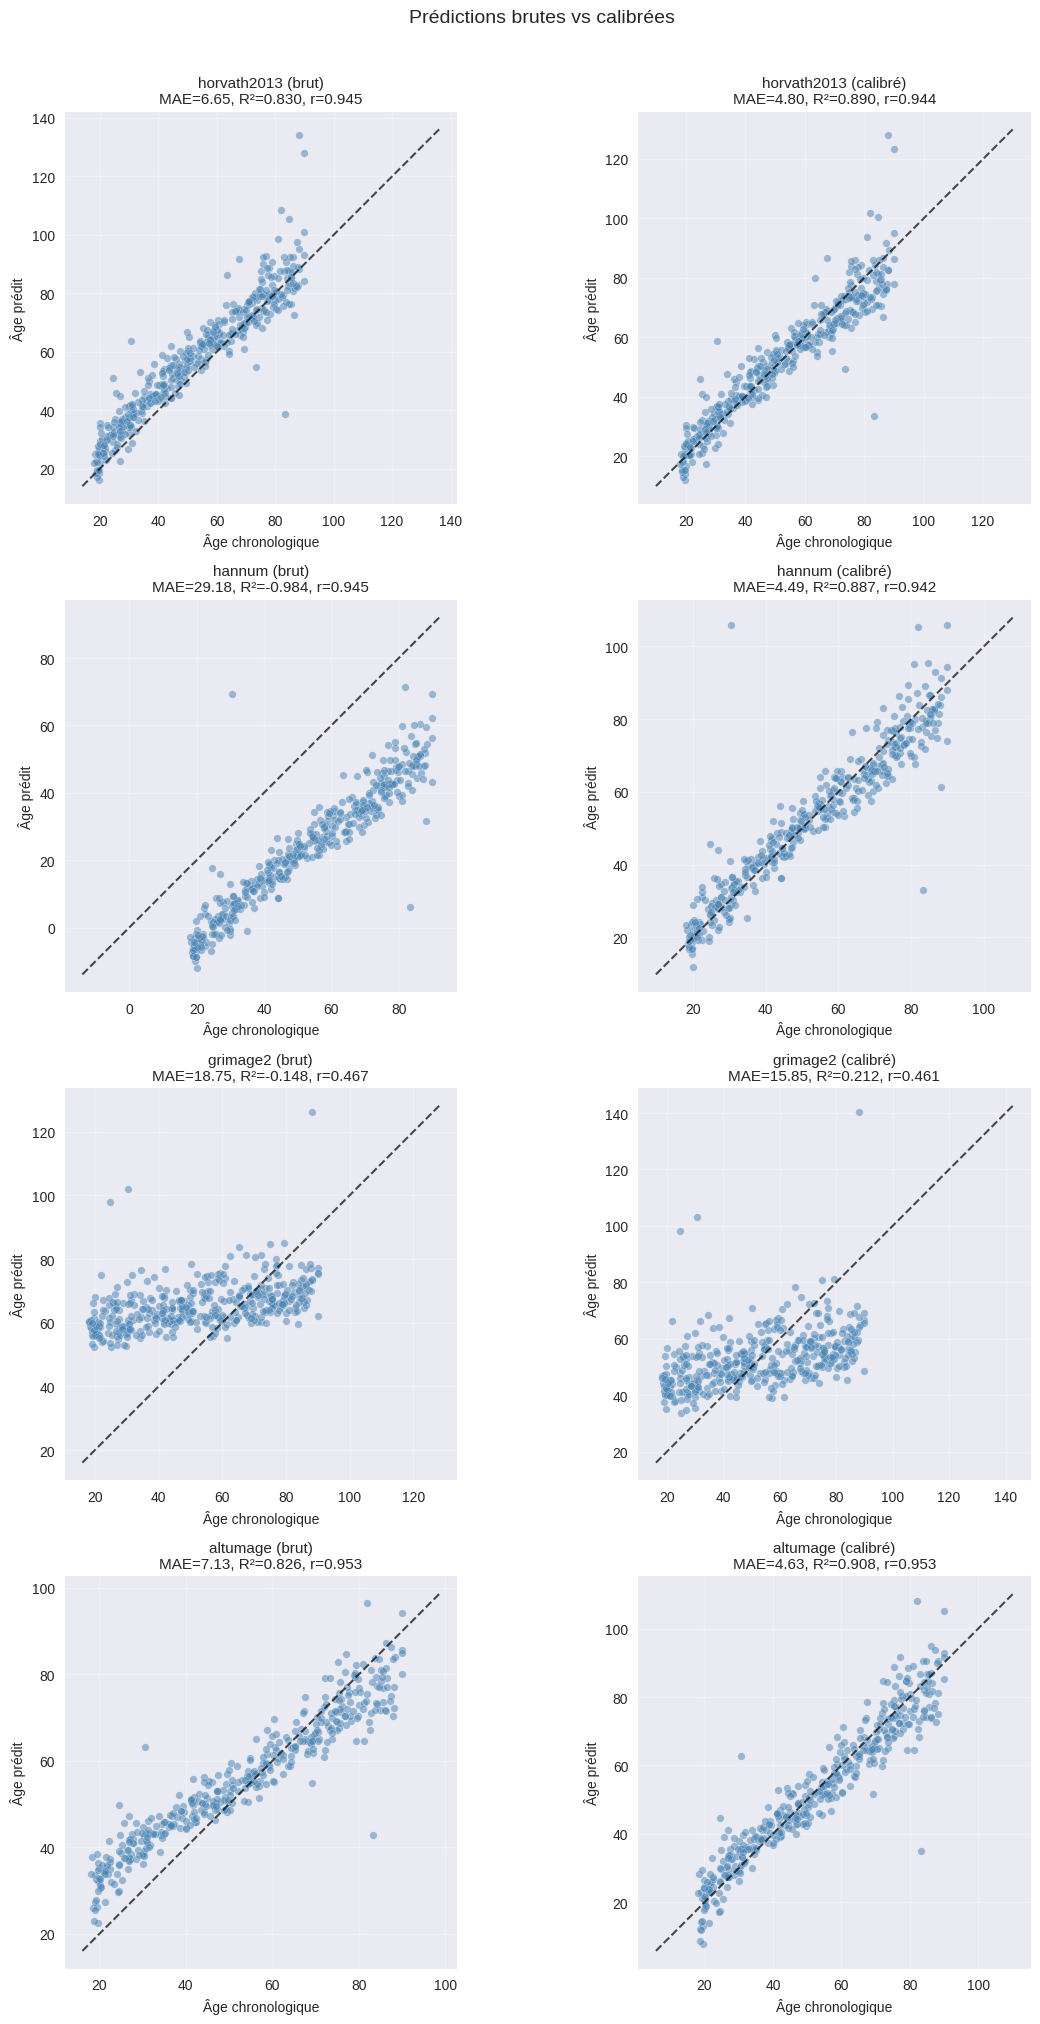

In [136]:
# Figure 1 : Scatter plots brut vs calibré pour chaque horloge
n_clocks = len(age_clocks)
fig, axes = plt.subplots(n_clocks, 2, figsize=(12, 5 * n_clocks))
if n_clocks == 1:
    axes = axes.reshape(1, -1)

for i, clock_col in enumerate(age_clocks):
    for j, (version, label) in enumerate([('brut', clock_col), ('calibré', f'{clock_col}_cal')]):
        ax = axes[i, j]
        y_pred = adata.obs[label].values.astype(float)
        valid = ~(np.isnan(y_pred) | np.isnan(y_true))
        yt, yp = y_true[valid], y_pred[valid]
        
        mae = mean_absolute_error(yt, yp)
        r2 = r2_score(yt, yp)
        pearson_r = stats.pearsonr(yt, yp)[0]
        
        ax.scatter(yt, yp, alpha=0.5, s=30, c='steelblue', edgecolors='white', linewidths=0.3)
        
        lims = [min(yt.min(), yp.min()) - 2, max(yt.max(), yp.max()) + 2]
        ax.plot(lims, lims, 'k--', linewidth=1.5, alpha=0.7)
        
        ax.set_xlabel('Âge chronologique', fontsize=10)
        ax.set_ylabel('Âge prédit', fontsize=10)
        ax.set_title(f'{clock_col} ({version})\nMAE={mae:.2f}, R²={r2:.3f}, r={pearson_r:.3f}', fontsize=11)
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)

plt.suptitle('Prédictions brutes vs calibrées', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

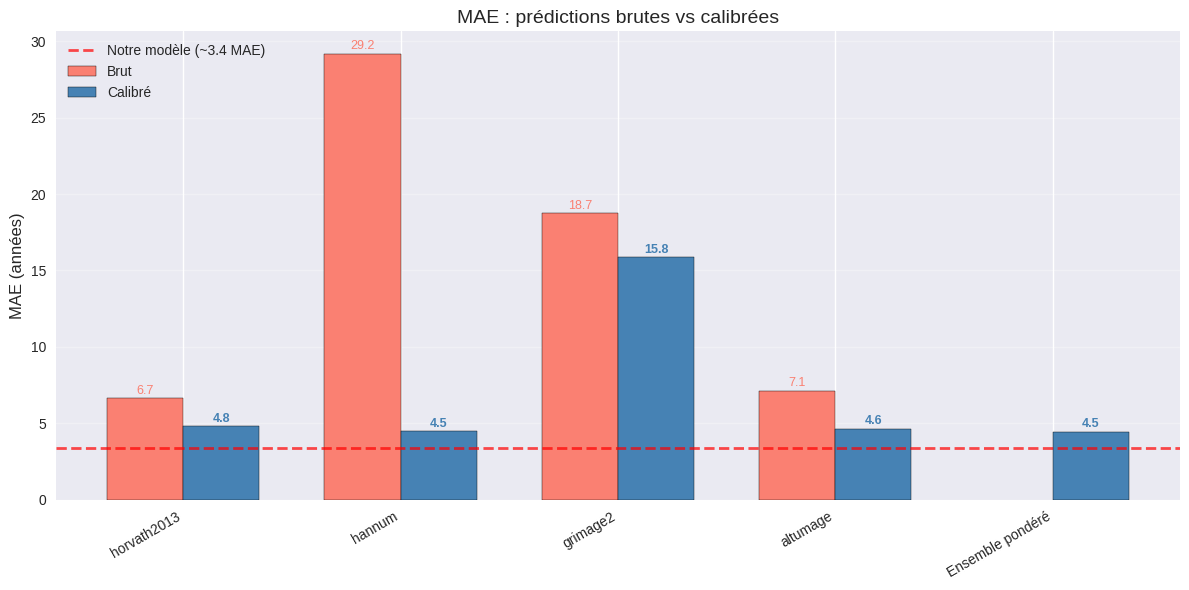

In [137]:
# Figure 2 : Barplot MAE brut vs calibré
fig, ax = plt.subplots(figsize=(12, 6))

clock_names = [c for c in age_clocks]
mae_raw = [mean_absolute_error(y_true, adata.obs[c].values.astype(float)) for c in clock_names]
mae_cal = [mean_absolute_error(y_true, calibrated_preds[c]) for c in clock_names]

# Ajouter l'ensemble
clock_names.append('Ensemble pondéré')
mae_raw.append(np.nan)
mae_cal.append(mae_ens_weighted)

x = np.arange(len(clock_names))
width = 0.35

bars1 = ax.bar(x - width/2, mae_raw, width, label='Brut', color='salmon', edgecolor='black')
bars2 = ax.bar(x + width/2, mae_cal, width, label='Calibré', color='steelblue', edgecolor='black')

# Annotations
for i, (raw, cal) in enumerate(zip(mae_raw, mae_cal)):
    if not np.isnan(raw):
        ax.text(i - width/2, raw + 0.3, f'{raw:.1f}', ha='center', fontsize=9, color='salmon')
    if not np.isnan(cal):
        ax.text(i + width/2, cal + 0.3, f'{cal:.1f}', ha='center', fontsize=9, fontweight='bold', color='steelblue')

ax.axhline(3.4, color='red', linestyle='--', alpha=0.7, linewidth=2, label='Notre modèle (~3.4 MAE)')
ax.set_xticks(x)
ax.set_xticklabels(clock_names, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('MAE (années)', fontsize=12)
ax.set_title('MAE : prédictions brutes vs calibrées', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

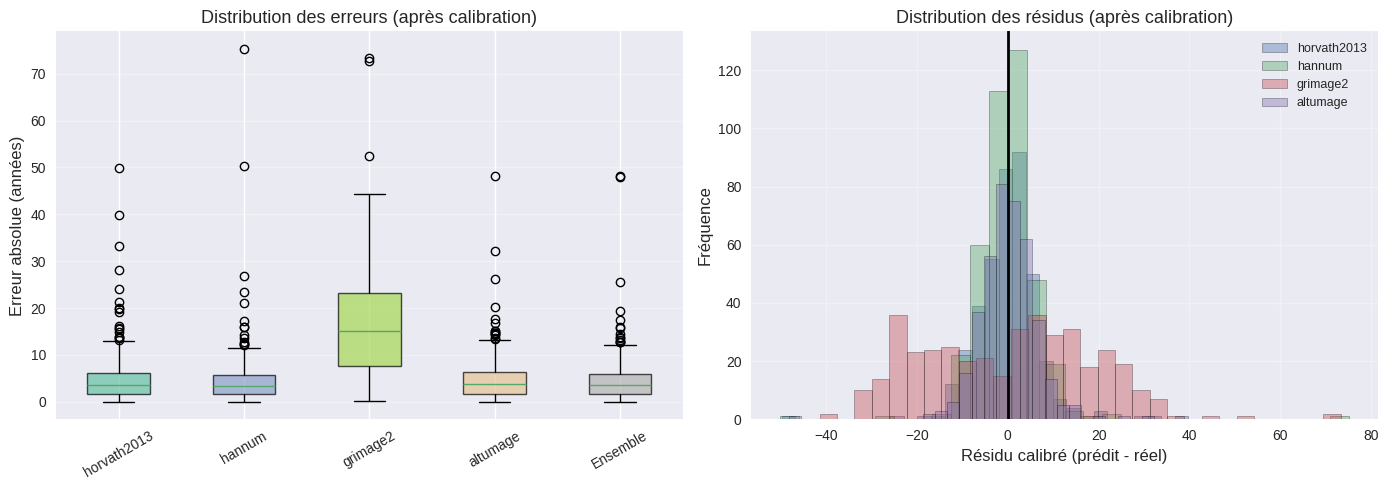

In [138]:
# Figure 3 : Distribution des erreurs (calibrées) et résidus
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot erreurs absolues calibrées
ax = axes[0]
error_data, error_labels = [], []
for clock_col in age_clocks:
    y_cal = calibrated_preds[clock_col]
    error_data.append(np.abs(y_true - y_cal))
    error_labels.append(clock_col)
# Ajouter ensemble
error_data.append(np.abs(y_true - ensemble_weighted))
error_labels.append('Ensemble')

bp = ax.boxplot(error_data, labels=error_labels, patch_artist=True, vert=True)
colors_box = plt.cm.Set2(np.linspace(0, 1, len(error_data)))
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('Erreur absolue (années)', fontsize=12)
ax.set_title('Distribution des erreurs (après calibration)', fontsize=13)
ax.tick_params(axis='x', rotation=30)
ax.grid(True, alpha=0.3, axis='y')

# Histogramme résidus calibrés
ax = axes[1]
for clock_col in age_clocks:
    y_cal = calibrated_preds[clock_col]
    ax.hist(y_cal - y_true, bins=30, alpha=0.4, label=clock_col,
            edgecolor='black', linewidth=0.5)
ax.axvline(0, color='black', linestyle='-', linewidth=2)
ax.set_xlabel('Résidu calibré (prédit - réel)', fontsize=12)
ax.set_ylabel('Fréquence', fontsize=12)
ax.set_title('Distribution des résidus (après calibration)', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

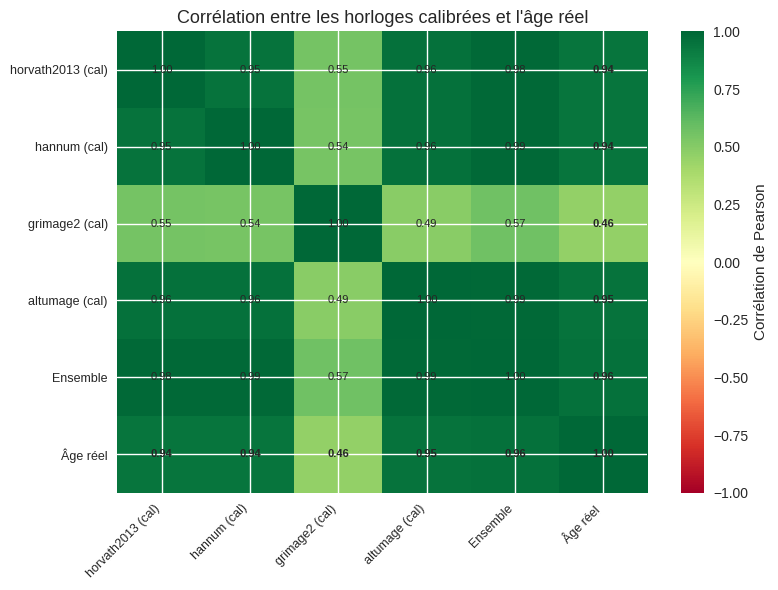

In [139]:
# Figure 4 : Corrélation entre horloges calibrées (heatmap)
cal_cols = [f'{c}_cal' for c in age_clocks] + ['ensemble_cal']
cal_labels = [f'{c} (cal)' for c in age_clocks] + ['Ensemble']

pred_matrix = adata.obs[cal_cols].astype(float).copy()
pred_matrix.columns = cal_labels
pred_matrix['Âge réel'] = y_true
corr = pred_matrix.corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
labels = list(corr.columns)
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(labels, fontsize=9)
for i in range(len(labels)):
    for j in range(len(labels)):
        weight = 'bold' if i == len(labels)-1 or j == len(labels)-1 else 'normal'
        ax.text(j, i, f'{corr.values[i, j]:.2f}', ha='center', va='center',
                fontsize=8, fontweight=weight)
plt.colorbar(im, ax=ax, label='Corrélation de Pearson')
ax.set_title('Corrélation entre les horloges calibrées et l\'âge réel', fontsize=13)
plt.tight_layout()
plt.show()

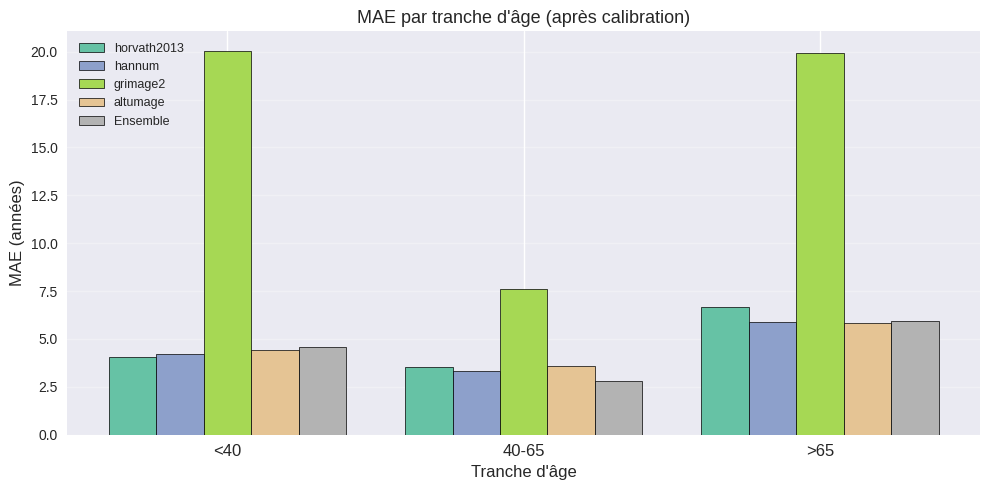

In [140]:
# Figure 5 : MAE par tranche d'âge (calibré)
fig, ax = plt.subplots(figsize=(10, 5))

plot_clocks = age_clocks + ['ensemble']
plot_labels = age_clocks + ['Ensemble']
plot_preds = {c: calibrated_preds[c] for c in age_clocks}
plot_preds['ensemble'] = ensemble_weighted

x = np.arange(len(age_groups))
width = 0.8 / max(len(plot_clocks), 1)
group_colors = plt.cm.Set2(np.linspace(0, 1, len(plot_clocks)))

for i, (clock_key, clock_label) in enumerate(zip(plot_clocks, plot_labels)):
    y_pred = plot_preds[clock_key]
    maes = []
    for (low, high) in age_groups.values():
        mask = (y_true >= low) & (y_true < high)
        maes.append(mean_absolute_error(y_true[mask], y_pred[mask]) if mask.sum() > 0 else 0)
    offset = (i - len(plot_clocks) / 2 + 0.5) * width
    ax.bar(x + offset, maes, width, label=clock_label, color=group_colors[i],
           edgecolor='black', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(list(age_groups.keys()), fontsize=12)
ax.set_xlabel('Tranche d\'âge', fontsize=12)
ax.set_ylabel('MAE (années)', fontsize=12)
ax.set_title('MAE par tranche d\'âge (après calibration)', fontsize=13)
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [141]:
# Résumé final
print('=' * 70)
print('RÉSUMÉ - HORLOGES ÉPIGÉNÉTIQUES : BRUT → CALIBRÉ → STACKING')
print('=' * 70)

print(f'\nDataset : {len(common_ids)} échantillons, EPICv2')
print(f'Âge : {y_true.min():.1f} - {y_true.max():.1f} ans (moyenne {y_true.mean():.1f})')
print(f'CpG chargés : {adata.shape[1]:,} (sur 894,006 totaux)')

print(f'\n--- 1. Performances brutes ---')
for clock_col in age_clocks:
    y_raw = adata.obs[clock_col].values.astype(float)
    mae_r = mean_absolute_error(y_true, y_raw)
    bias_r = np.mean(y_raw - y_true)
    print(f'  {clock_col:20s} : MAE = {mae_r:6.2f}, biais = {bias_r:+.1f}')

print(f'\n--- 2. Après calibration linéaire (CV 5-fold) ---')
for clock_col in age_clocks:
    y_cal = calibrated_preds[clock_col]
    mae_c = mean_absolute_error(y_true, y_cal)
    r2_c = r2_score(y_true, y_cal)
    print(f'  {clock_col:20s} : MAE = {mae_c:6.2f}, R² = {r2_c:.3f}')
print(f'  {"Ensemble pondéré":20s} : MAE = {mae_ens_weighted:6.2f}')

print(f'\n--- 3. Stacking multi-horloges + démographie ---')
print(f'  {best_config_name}')
print(f'  MAE = {best_mae:.2f}, R² = {r2_score(y_true, best_stacked_preds):.3f}')

print(f'\n--- Comparaison finale ---')
print(f'  Horloges brutes (meilleure)  : MAE ~6.7')
print(f'  Calibration individuelle     : MAE ~4.5')
print(f'  Stacking + démographie       : MAE = {best_mae:.2f}')
print(f'  Notre modèle custom          : MAE ~3.3-3.5')
print(f'\n  → Notre modèle spécifique surpasse les horloges pré-entraînées.')
print(f'    C\'est normal : il utilise 894k CpG vs 4 prédictions d\'horloges.')
print('=' * 70)

RÉSUMÉ - HORLOGES ÉPIGÉNÉTIQUES : BRUT → CALIBRÉ → STACKING

Dataset : 400 échantillons, EPICv2
Âge : 18.1 - 90.0 ans (moyenne 53.0)
CpG chargés : 36,823 (sur 894,006 totaux)

--- 1. Performances brutes ---
  horvath2013          : MAE =   6.65, biais = +5.3
  hannum               : MAE =  29.18, biais = -29.0
  grimage2             : MAE =  18.75, biais = +12.6
  altumage             : MAE =   7.13, biais = +3.1

--- 2. Après calibration linéaire (CV 5-fold) ---
  horvath2013          : MAE =   4.80, R² = 0.890
  hannum               : MAE =   4.49, R² = 0.887
  grimage2             : MAE =  15.85, R² = 0.212
  altumage             : MAE =   4.63, R² = 0.908
  Ensemble pondéré     : MAE =   4.46

--- 3. Stacking multi-horloges + démographie ---
  Top-3 + sexe + ethnie + Ridge(10)
  MAE = 3.93, R² = 0.919

--- Comparaison finale ---
  Horloges brutes (meilleure)  : MAE ~6.7
  Calibration individuelle     : MAE ~4.5
  Stacking + démographie       : MAE = 3.93
  Notre modèle custom      

In [142]:
# Citations
print('=== Citations ===')
for clock in CLOCKS:
    try:
        pya.utils.cite_clock(clock)
        print()
    except Exception:
        print(f'{clock}: citation non disponible\n')

=== Citations ===
|-----> 🏗️ Starting cite_clock function
|-----> ⚙️ Load all clock metadata started
|-----------> Data found in pyaging_data/all_clock_metadata.pt
|-----> ✅ Load all clock metadata finished [0.0034s]
|-----> ⚙️ Searching for citation of clock horvath2013 started
|-----------> Citation for horvath2013:
|-----------> Horvath, Steve. "DNA methylation age of human tissues and cell types." Genome biology 14.10 (2013): 1-20.
|-----------> Please also consider citing pyaging :)
|-----------> de Lima Camillo, Lucas Paulo. "pyaging: a Python-based compendium of GPU-optimized aging clocks." bioRxiv (2023): 2023-11.
|-----> ✅ Searching for citation of clock horvath2013 finished [0.0023s]
|-----> 🎉 Done! [0.0087s]

|-----> 🏗️ Starting cite_clock function
|-----> ⚙️ Load all clock metadata started
|-----------> Data found in pyaging_data/all_clock_metadata.pt
|-----> ✅ Load all clock metadata finished [0.0027s]
|-----> ⚙️ Searching for citation of clock hannum started
|----------->